In [40]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn import svm
#from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.model_selection import train_test_split

from sklearn.model_selection import cross_validate, GridSearchCV, KFold, cross_val_score
#from sklearn.metrics import recall_score

#from sklearn import preprocessing
from sklearn.preprocessing import RobustScaler, StandardScaler



In [68]:
INPUT_DIR        = "data/input"
MODEL_INPUT_DIR  = f"{INPUT_DIR}/formatted-input"
#MODEL_INPUT_FILE = f"{MODEL_INPUT_DIR}/model_input_traintest_cleavedSelf9k_hex_noID.csv"#model_input_traintest_randselfpeps_commonAlleles_nomhcnuggs_newPath.csv"#model_input_traintest_randselfpeps_new_pathogenicity.csv"#" #"model_input_imm_and_mhc-nb_m1_t7.csv"#"#"model_input_all_traintest.csv"
#MODEL_INPUT_FILE = f"{MODEL_INPUT_DIR}/model_input_traintest_cleavedself9k_di_selfNoID.csv"
# MODEL_INPUT_FILE = f"{MODEL_INPUT_DIR}/testMTEC_raw_featureTable_traintest_9kcleavedself.csv"
#MODEL_INPUT_FILE = f"data/selfsimilarity/selfsim_noID_combined.csv"
#FEATURE_TABLE    = f"{MODEL_INPUT_DIR}/featureTable1.csv"
MODEL_INPUT_FILE = f"{MODEL_INPUT_DIR}/traintest_9kcleavedself_featureTable.csv"

#ALL_PEPS_FILE    = f"{INPUT_DIR}/cedar_randself_mhc-nbs.txt"

IMM_PEP_FILE     = f"{INPUT_DIR}/cedar_imm_peps_traintest.txt"#cedar_imm_9mers.txt"  #cedar_Immunogenic_self_df.txt"        #cedar_imm_peps_traintest.txt"
NON_IMM_PEP_FILE = f"{INPUT_DIR}/9kcleavedrandselfpeps.txt"#cedar_non-imm_9mers.txt"##randselfpeps~10k.txt"#cedar_non-imm_and_self_55.txt"#" #" #cedar_non_imm_peps_traintest.txt" #" #" randselfpeps~10k.txt cedar_non-imm_and_self_10    #"#randselfpeps~10k.txt"#random_in_silico_peptides.txt"#non_mhc_binding_peptides.txt"#"
#NON_IMM_PEP_FILE = f"{INPUT_DIR}/cedar_non_imm_peps_traintest.txt"
#NON_IMM_PEP_FILE = f"{INPUT_DIR}/9kcleavedselfpeps_nonBinders.txt"
NON_IMM_LABEL = "Non Imm"

# VALIDATION_MODEL_INPUT_FILE =  f"{MODEL_INPUT_DIR}/model_input_hormad1-magea4.csv"
# VALIDATION_PEPTIDES_FILE = f"{INPUT_DIR}/hormad1-magea4_cleavedPeps.txt"

## Load the Data

In [69]:
X_df = pd.read_csv(MODEL_INPUT_FILE)
#X_df = pd.read_csv(FEATURE_TABLE)
display(X_df[X_df['peptide'].str.contains('pep')])

# X_validation_df = pd.read_csv(VALIDATION_MODEL_INPUT_FILE)

,peptide,best_rank,avg_rank,strong_binders_count,weak_binders_count,best_netmhc_r,netmhc_a,best_mixmhc_r,mixmhc_a,best_mhcflurry_r,...,di_avg_score,di_best_a_score,di_avg_a_score,di_best_b_score,di_avg_b_score,di_best_c_score,di_avg_c_score,PRIME_%Rank_bestAllele,similarity_score,tap_score


In [70]:
X_df.drop_duplicates(subset=['peptide'], inplace=True)
X_df.sort_values(by='peptide', inplace=True)

display(X_df.shape)

(29298, 24)

#### Adding peptide length as a feature

In [71]:
X_df['length'] = X_df['peptide'].str.len()

#### 8mer missingness

In [72]:
print(f"Num 8mers in set with NaN for deepimmuno: {X_df[X_df['di_best_score'].isna()].shape[0]}")

Num 8mers in set with NaN for deepimmuno: 1146


Drop Any Unwanted features

In [73]:
X_df = X_df.drop(columns=['Num_Tools_0_01', 'Num_Tools_0_02',
       'Num_Tools_0_03', 'Num_Tools_0_04', 'Num_Tools_1', 'Num_Tools_2', 'Num_Tools_Super_Strong_Binder',
       'Num_Tools_Strong_Binder', 'Num_Tools_Weak_Binder',
       'Num_Tools_Super_Weak_Binder'], errors='ignore')

# Uncomment for main figures
X_df = X_df.drop(columns=['best_allele', 'best_netmhc_r', 'best_mixmhc_r', 'best_mhcflurry_r', 'best_mhcnuggets_r', 
       'netmhc_a', 'mixmhc_a', 'mhcflurry_a', 'mhcnuggets_a'], errors='ignore')

X_df = X_df.drop(columns=['di_avg_score', 'di_best_a_score', 'di_avg_a_score', 'di_best_b_score', 'best_rank', 'strong_binders_count',
       'di_avg_b_score', 'di_best_c_score', 'di_avg_c_score', 'similarity_score', 'tap_score', 'length'], errors='ignore')

# Supp figures distributions
# X_df = X_df.drop(columns=['best_allele', 'best_netmhc_r', 'best_mixmhc_r', 'best_mhcflurry_r', 'best_mhcnuggets_r', 
#        'netmhc_a', 'mixmhc_a', 'mhcflurry_a', 'mhcnuggets_a'], errors='ignore')

# X_df = X_df.drop(columns=['di_avg_score', 'di_best_a_score', 'di_avg_a_score', 'di_best_b_score', 'best_rank',
#        'di_avg_b_score', 'di_best_c_score', 'di_avg_c_score', 'avg_rank', 'weak_binders_count', 'mtec_expression_count',
#        'pathogenicity', 'di_best_score', 'PRIME_%Rank_bestAllele'], errors='ignore')


display(X_df.shape)

(29298, 7)

change column names for figure

In [74]:
X_df.rename(columns={'avg_rank' : 'HLA Rank', 'weak_binders_count' : 'HLA WBC', 'mtec_expression_count' : 'mTEC Expr.', 'pathogenicity' : 'Viral Similarity', 'di_best_score' : 'DeepImmuno', 'PRIME_%Rank_bestAllele' : 'PRIME Rank', 'length' : 'Length', 'similarity_score' : 'Self Similarity', 'tap_score' : 'DeepTAP', 'strong_binders_count' : 'HLA SBC'}, inplace=True)

In [75]:
feature_cols = X_df.drop(columns='peptide').columns
print(feature_cols)

Index(['HLA Rank', 'HLA WBC', 'mTEC Expr.', 'Viral Similarity', 'DeepImmuno',
       'PRIME Rank'],
      dtype='str')


## Visualize data

Violin Plots

In [76]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import matplotlib.font_manager as fm
import glob

FONT_DIR = "fonts"
for f in glob.glob(os.path.join(FONT_DIR, "*.ttf")):
    fm.fontManager.addfont(f)

sns.set_style("ticks")
plt.rcParams['font.family'] = 'Carlito'

AXIS_LABEL_FONTSIZE = 20
TICK_LABEL_FONTSIZE = 14
LEGEND_FONTSIZE = 16
POINT_LABEL_FONTSIZE = 14
LINEWIDTH_MAIN = 2
LINEWIDTH_REF = 1.5

PALETTE = {
    'CEDAR-pos': '#6AB9EC',
    'CEDAR-neg': '#E26CE1',
    'Random Self': '#7FD194',
}

In [77]:
CEDAR_IMM           = 'data/input/cedar_imm_peps_traintest.txt'
CEDAR_NON_IMM       = 'data/input/cedar_non_imm_peps_traintest.txt'
RAND_CLEAVED_SELF   = 'data/input/9kcleavedrandselfpeps.txt'

imm_peps        = pd.read_csv(CEDAR_IMM, header=None)[0].to_list()
non_imm_peps    = pd.read_csv(CEDAR_NON_IMM, header=None)[0].to_list()
self_peps       = pd.read_csv(RAND_CLEAVED_SELF, header=None)[0].to_list()

In [78]:
import numpy as np
from scipy.stats import wasserstein_distance, ks_2samp

def cliffs_delta(x, y):
    """Cliff's delta effect size between two 1D arrays."""
    x = np.asarray(x)
    y = np.asarray(y)
    nx, ny = len(x), len(y)
    diff = x[:, None] - y[None, :]
    more = np.sum(diff > 0)
    less = np.sum(diff < 0)
    return (more - less) / (nx * ny)

def compare_to_reference(plot_df, feature, reference_group='Immunogenic'):
    ref_vals = plot_df.loc[plot_df['group'] == reference_group, 'value']
    results = {}
    for g in plot_df['group'].unique():
        if g == reference_group:
            continue
        other_vals = plot_df.loc[plot_df['group'] == g, 'value']
        delta = cliffs_delta(ref_vals, other_vals)
        wass = wasserstein_distance(ref_vals, other_vals)
        ks_stat, _ = ks_2samp(ref_vals, other_vals)  # ignore p-value
        results[g] = {'cliffs_delta': delta, 'wasserstein': wass, 'ks_stat': ks_stat}
    return results

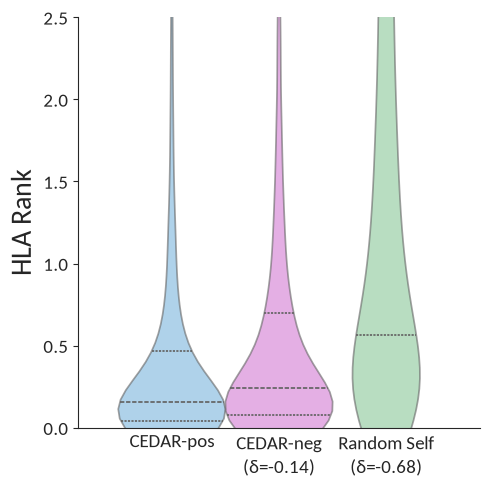

Saved: feature_distributions/HLA_Rank_violin.png


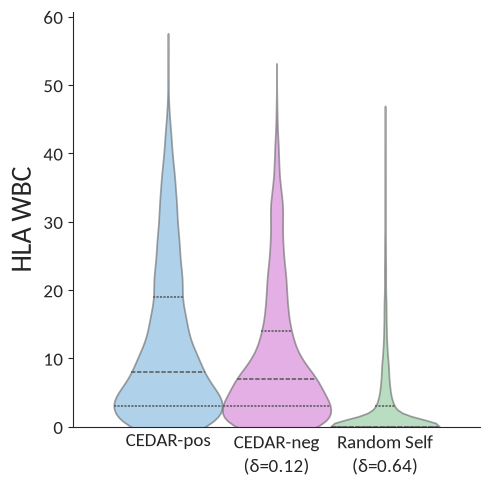

Saved: feature_distributions/HLA_WBC_violin.png


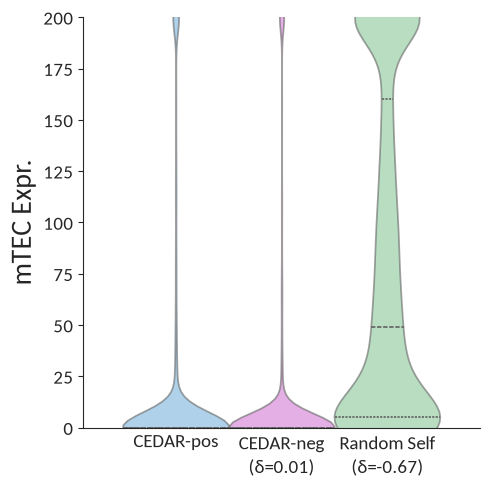

Saved: feature_distributions/mTEC_Expr_violin.png


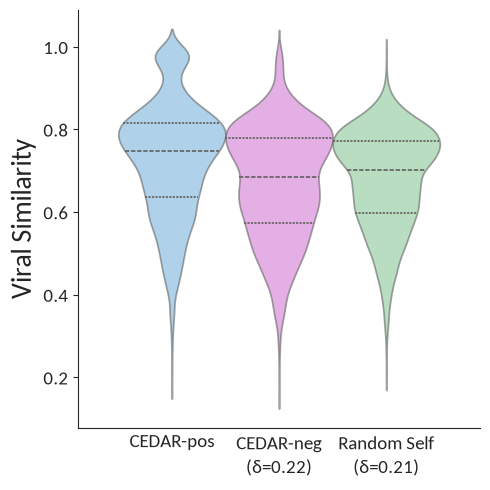

Saved: feature_distributions/Viral_Similarity_violin.png


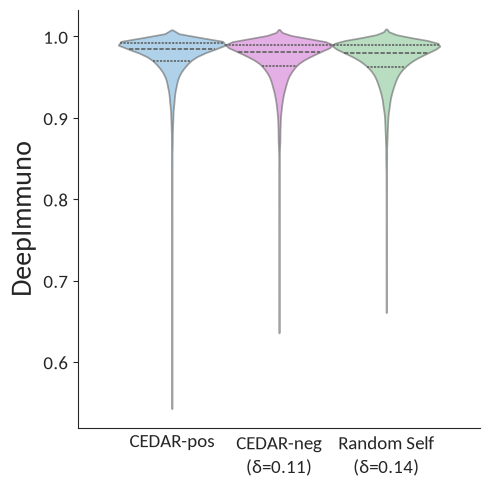

Saved: feature_distributions/DeepImmuno_violin.png


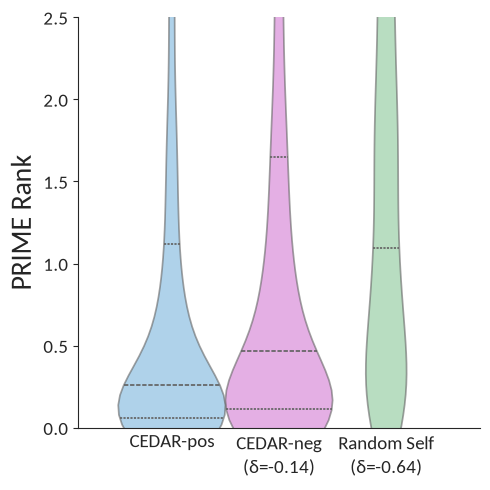

Saved: feature_distributions/PRIME_Rank_violin.png


In [79]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

def plotViolinsSplit(X_df, feature_cols, groups, custom_palette=None, output_dir=".", reference_group='CEDAR-pos', violin_width=0.8):
    # Create the output directory if it doesn't exist
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    peptide_to_group = {}
    for group_name, peptides in groups.items():
        for pep in peptides:
            peptide_to_group[pep] = group_name

    df = X_df.copy()
    df['group'] = df['peptide'].map(peptide_to_group)
    df = df[df['group'].notna()]

    group_labels = list(groups.keys())
    n_groups = len(group_labels)
    can_split = len(group_labels) == 2
    
    for feature in feature_cols:
        fig, ax = plt.subplots(figsize=(5, 5))
        
        col = df[feature]
        
        restrict_range = ('Rank' in feature) or ('PRIME' in feature)
        cap_mtec_expression = (feature == 'mTEC Expr.')

        vals = col.copy()
        if restrict_range:
            vals = vals.clip(0, 5)
        elif cap_mtec_expression:
            vals = vals.clip(0, 200)

        plot_df = pd.DataFrame({'value': vals, 'group': df['group'], 'x': feature})
        plot_df = plot_df.dropna(subset=['value'])

        sns.violinplot(
            data=plot_df, x='x', y='value', hue='group', split=can_split,
            ax=ax, hue_order=group_labels, inner='quartile', alpha=0.6, legend=False,
            palette=custom_palette, #cut=0 
        )

        ## TESTING EFFECT SIZES

        effect_sizes = compare_to_reference(plot_df, feature, reference_group=reference_group)

        tick_positions = []
        tick_labels = []
        tick_colors = []
        for i, g in enumerate(group_labels):
            offset = (i - (n_groups - 1) / 2) * (violin_width / n_groups)
            tick_positions.append(offset)
            if g == reference_group:
                tick_labels.append(g)  # reference group: just its name, no delta
            else:
                delta = effect_sizes[g]['cliffs_delta']
                tick_labels.append(f"{g}\n(δ={delta:.2f})")
            tick_colors.append(custom_palette.get(g, 'black') if custom_palette else 'black')

        ax.set_xticks(tick_positions)
        # Tick and axis label sizes standardised across thesis figures
        ax.set_xticklabels(tick_labels, fontsize=TICK_LABEL_FONTSIZE)
        ax.tick_params(axis='x', length=0)
        ax.tick_params(axis='y', labelsize=TICK_LABEL_FONTSIZE)

        ax.spines[['top', 'right']].set_visible(False)
        ax.set_xlabel('')
        ax.set_ylabel(feature, fontsize=AXIS_LABEL_FONTSIZE)
        # ax.set_xticks([]) 

        if restrict_range:
            ax.set_ylim(0, 2.5)
        elif cap_mtec_expression:
            ax.set_ylim(0, 200)
        elif feature == 'HLA WBC' or feature == 'HLA SBC': 
            ax.set_ylim(bottom=0)
            
        plt.tight_layout()
        
        safe_filename = feature.replace(" ", "_").replace(".", "").replace("/", "_")
        filepath = os.path.join(output_dir, f"{safe_filename}_violin.png")
        #plt.savefig(filepath, dpi=300, bbox_inches='tight')
        plt.show()
        
        plt.close(fig)
        print(f"Saved: {filepath}")


plotViolinsSplit(
    X_df, 
    feature_cols, 
    {'CEDAR-pos': imm_peps, 'CEDAR-neg': non_imm_peps, 'Random Self': self_peps},
    custom_palette=PALETTE,
    output_dir="feature_distributions" 
)
# def plotViolinsSplit(X_df, feature_cols, groups, custom_palette=None, output_dir=".", reference_group='CEDAR-pos', violin_width=0.8):
#     # Create the output directory if it doesn't exist
#     if not os.path.exists(output_dir):
#         os.makedirs(output_dir)

#     peptide_to_group = {}
#     for group_name, peptides in groups.items():
#         for pep in peptides:
#             peptide_to_group[pep] = group_name

#     df = X_df.copy()
#     df['group'] = df['peptide'].map(peptide_to_group)
#     df = df[df['group'].notna()]

#     group_labels = list(groups.keys())
#     n_groups = len(group_labels)
#     can_split = len(group_labels) == 2
    
#     for feature in feature_cols:
#         fig, ax = plt.subplots(figsize=(5, 5))
        
#         col = df[feature]
        
#         restrict_range = ('Rank' in feature) or ('PRIME' in feature)
#         cap_mtec_expression = (feature == 'mTEC Expr.')

#         vals = col.copy()
#         if restrict_range:
#             vals = vals.clip(0, 5)
#         elif cap_mtec_expression:
#             vals = vals.clip(0, 200)

#         plot_df = pd.DataFrame({'value': vals, 'group': df['group'], 'x': feature})
#         plot_df = plot_df.dropna(subset=['value'])

#         sns.violinplot(
#             data=plot_df, x='x', y='value', hue='group', split=can_split,
#             ax=ax, hue_order=group_labels, inner='quartile', alpha=0.6, legend=False,
#             palette=custom_palette, #cut=0 
#         )

#         ## TESTING EFFECT SIZES

#         effect_sizes = compare_to_reference(plot_df, feature, reference_group=reference_group)

#         tick_positions = []
#         tick_labels = []
#         tick_colors = []
#         for i, g in enumerate(group_labels):
#             offset = (i - (n_groups - 1) / 2) * (violin_width / n_groups)
#             tick_positions.append(offset)
#             if g == reference_group:
#                 tick_labels.append(g)  # reference group: just its name, no delta
#             else:
#                 delta = effect_sizes[g]['cliffs_delta']
#                 tick_labels.append(f"{g}\n(δ={delta:.2f})")
#             tick_colors.append(custom_palette.get(g, 'black') if custom_palette else 'black')

#         ax.set_xticks(tick_positions)
#         ax.set_xticklabels(tick_labels, fontsize=10)
#         ax.tick_params(axis='x', length=0)

#         ax.spines[['top', 'right']].set_visible(False)
#         ax.set_xlabel('')
#         ax.set_ylabel(feature)
#         # ax.set_xticks([]) 

#         if restrict_range:
#             ax.set_ylim(0, 2.5)
#         elif cap_mtec_expression:
#             ax.set_ylim(0, 200)
#         elif feature == 'HLA WBC': 
#             ax.set_ylim(bottom=0)
            
#         plt.tight_layout()
        
#         safe_filename = feature.replace(" ", "_").replace(".", "").replace("/", "_")
#         filepath = os.path.join(output_dir, f"{safe_filename}_violin.png")
#         plt.savefig(filepath, dpi=300, bbox_inches='tight')
#         plt.show()
        
#         plt.close(fig)
#         print(f"Saved: {filepath}")

# cp = {
#     'CEDAR-pos': '#6AB9EC', #95CAEC',
#     'CEDAR-neg': '#E26CE1', #E290E1',
#     'Random Self': '#7FD194' #AAD1B4' 
# }

# plotViolinsSplit(
#     X_df, 
#     feature_cols, 
#     {'CEDAR-pos': imm_peps, 'CEDAR-neg': non_imm_peps, 'Random Self': self_peps},
#     custom_palette=cp,
#     output_dir="feature_distributions" 
# )

In [46]:
# import seaborn as sns
# import pandas as pd

# def plotViolinsSplit(X, feature_cols, labels):
#     fig, axes = plt.subplots(nrows=len(feature_cols) // 4 + 1, ncols=4, figsize=(16, 4 * (len(feature_cols) // 4 + 1)))
#     axes = axes.flatten()

#     for i, feature in enumerate(feature_cols):
#         col = X[:, i]
#         not_nan = ~np.isnan(col)
#         mask = not_nan & np.isin(y, [0, 1])

#         vals = col[mask]
#         groups = np.where(y[mask] == 1, labels[0], labels[1])

#         n_missing = np.isnan(col).sum()
#         pct_missing = 100 * n_missing / len(col)

#         restrict_range = ('_r' in feature) or ('PRIME' in feature)
#         cap_mtec_expression = (feature == 'mtec_expression_count')

#         if restrict_range:
#             vals = np.clip(vals, 0, 5)
#         elif cap_mtec_expression:
#             vals = np.clip(vals, 0, 200)

#         df = pd.DataFrame({'value': vals, 'group': groups, 'x': feature})

#         sns.violinplot(
#             data=df, x='x', y='value', hue='group', split=True,
#             ax=axes[i], hue_order=labels, inner='quartile', alpha=0.6
#         )
#         axes[i].set_title(f'{feature} ({pct_missing:.1f}% missing)')
#         axes[i].set_xlabel('')
#         axes[i].set_ylabel(feature)
#         axes[i].legend(loc='upper right', fontsize=8)

#         if restrict_range:
#             axes[i].set_ylim(0, 2.5)
#         elif cap_mtec_expression:
#             axes[i].set_ylim(0, 200)

#     for j in range(i + 1, len(axes)):
#         axes[j].set_visible(False)

#     plt.tight_layout()
#     plt.show()

# #plotViolinsSplit(X, feature_cols, ['Immunogenic', NON_IMM_LABEL])
# plotViolinsSplit(X, feature_cols, ['Immunogenic', NON_IMM_LABEL])